In [ ]:
# Core libraries




































































































































































































































PyTorch version: 2.11.0+cpu


In [ ]:
!wget https://files.grouplens.org/datasets/movielens/ml-latest-small.zip
!unzip ml-latest-small.zip

--2026-05-28 01:20:21--  https://files.grouplens.org/datasets/movielens/ml-latest-small.zip
Resolving files.grouplens.org (files.grouplens.org)... 128.101.96.204
Connecting to files.grouplens.org (files.grouplens.org)|128.101.96.204|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 978202 (955K) [application/zip]
Saving to: ‘ml-latest-small.zip’

ml-latest-small.zip 100%[===================>] 955.28K  2.65MB/s    in 0.4s    

2026-05-28 01:20:22 (2.65 MB/s) - ‘ml-latest-small.zip’ saved [978202/978202]

Archive:  ml-latest-small.zip
   creating: ml-latest-small/
  inflating: ml-latest-small/links.csv  
  inflating: ml-latest-small/tags.csv  
  inflating: ml-latest-small/ratings.csv  
  inflating: ml-latest-small/README.txt  
  inflating: ml-latest-small/movies.csv  


In [ ]:
ratings_df = pd.read_csv("ml-latest-small/ratings.csv")
movies_df = pd.read_csv("ml-latest-small/movies.csv")

print(ratings_df.head())
print(movies_df.head())

   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  


In [ ]:
ratings = pd.read_csv("ml-latest-small/ratings.csv")

ratings['user'] = user_encoder.fit_transform(ratings['userId'])
ratings['movie'] = movie_encoder.fit_transform(ratings['movieId'])

Number of ratings: 100836
Number of users: 610
Number of movies: 9724


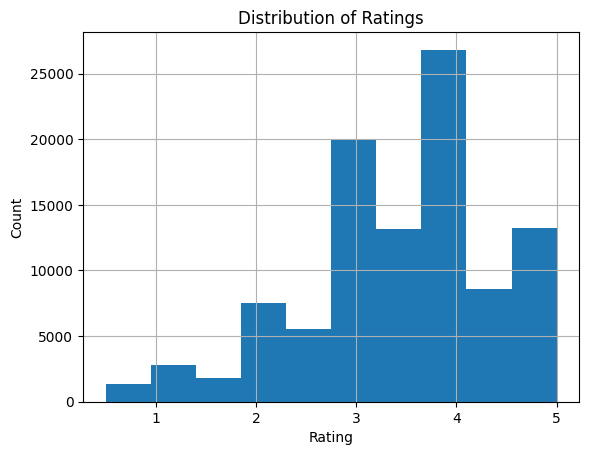

In [ ]:
print("Number of ratings:", len(ratings))
print("Number of users:", ratings['userId'].nunique())
print("Number of movies:", ratings['movieId'].nunique())

ratings['rating'].hist(bins=10)
plt.xlabel("Rating")
plt.ylabel("Count")
plt.title("Distribution of Ratings")
plt.show()

In [ ]:
user_encoder = LabelEncoder()
movie_encoder = LabelEncoder()

ratings_df['user'] = user_encoder.fit_transform(
    ratings_df['userId']
)

ratings_df['movie'] = movie_encoder.fit_transform(
    ratings_df['movieId']
)

num_users = ratings_df['user'].nunique()
num_movies = ratings_df['movie'].nunique()

print(num_users, num_movies)

610 9724


In [ ]:
train_df, test_df = train_test_split(
    ratings_df,
    test_size=0.2,
    random_state=42
)

print(len(train_df), len(test_df))

80668 20168


In [ ]:
class RatingsDataset(Dataset):
    def __init__(self, dataframe):
        self.users = torch.tensor(dataframe['user'].values)
        self.movies = torch.tensor(dataframe['movie'].values)
        self.ratings = torch.tensor(dataframe['rating'].values,
                                    dtype=torch.float32)

    def __len__(self):
        return len(self.users)

    def __getitem__(self, idx):
        return (
            self.users[idx],
            self.movies[idx],
            self.ratings[idx]
        )

In [ ]:
train_dataset = RatingsDataset(train_df)
test_dataset = RatingsDataset(test_df)

train_loader = DataLoader(train_dataset,
                          batch_size=256,
                          shuffle=True)

test_loader = DataLoader(test_dataset,
                         batch_size=256)


In [ ]:
class NeuralRecommender(nn.Module):

    def __init__(self,
                 num_users,
                 num_movies,
                 embedding_dim=64):

        super().__init__()

        # Embedding layers
        self.user_embedding = nn.Embedding(
            num_users,
            embedding_dim
        )

        self.movie_embedding = nn.Embedding(
            num_movies,
            embedding_dim
        )

        # Fully connected network
        self.fc_layers = nn.Sequential(

            nn.Linear(embedding_dim * 2, 128),
            nn.ReLU(),

            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 1)
        )

    def forward(self, user, movie):

        # Get embeddings
        user_embedded = self.user_embedding(user)
        movie_embedded = self.movie_embedding(movie)

        # Concatenate
        x = torch.cat(
            [user_embedded, movie_embedded],
            dim=1
        )

        # Pass through neural network
        output = self.fc_layers(x)

        return output.squeeze()

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = NeuralRecommender(
    num_users=num_users,
    num_movies=num_movies,
    embedding_dim=64
).to(device)

print(model)

NeuralRecommender(
  (user_embedding): Embedding(610, 64)
  (movie_embedding): Embedding(9724, 64)
  (fc_layers): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [ ]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [ ]:
epochs = 10

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for users, movies, batch_ratings in train_loader:

        users = users.to(device)
        movies = movies.to(device)
        batch_ratings = batch_ratings.to(device)

        # Forward pass
        predictions = model(users, movies)

        # Compute loss
        loss = criterion(predictions, batch_ratings)

        # Zero gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Update parameters
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f}")

Epoch 1/10 | Loss: 0.6491
Epoch 2/10 | Loss: 0.6418
Epoch 3/10 | Loss: 0.6277
Epoch 4/10 | Loss: 0.6179
Epoch 5/10 | Loss: 0.6124
Epoch 6/10 | Loss: 0.5999
Epoch 7/10 | Loss: 0.5927
Epoch 8/10 | Loss: 0.5820
Epoch 9/10 | Loss: 0.5720
Epoch 10/10 | Loss: 0.5590


In [ ]:
model.eval()

total_loss = 0

with torch.no_grad():

    for users, movies, batch_ratings in test_loader:

        users = users.to(device)
        movies = movies.to(device)
        batch_ratings = batch_ratings.to(device)

        predictions = model(users, movies)

        loss = criterion(predictions, batch_ratings)

        total_loss += loss.item()

avg_test_loss = total_loss / len(test_loader)

print("Test Loss:", avg_test_loss)

Test Loss: 0.8223615243465086


In [ ]:
movie_id_mapping = dict(
    zip(
        ratings_df['movie'],
        ratings_df['movieId']
    )
)

movie_titles = dict(
    zip(
        movies_df['movieId'],
        movies_df['title']
    )
)

""" Why This Exists

Remember:
we encoded movie IDs.

The model sees:

movie 0
movie 1
movie 2

But humans need:

Toy Story
The Matrix
Inception

So we map back. """

' Why This Exists\n\nRemember:\nwe encoded movie IDs.\n\nThe model sees:\n\nmovie 0\nmovie 1\nmovie 2\n\nBut humans need:\n\nToy Story\nThe Matrix\nInception\n\nSo we map back. '

In [ ]:
# RECOMMENDATION FUNCTION

""" Inputs:

model → trained neural recommender
user_id → user we want recommendations for
ratings_df → ratings dataset
top_k → number of recommendations """

def recommend_movies(model,
                     user_id,
                     ratings_df,
                     top_k=10):

    model.eval()

    """ During training:

dropout randomly turns neurons off.

During inference:

we want stable predictions.

So:

model.eval()

switches the network into inference mode.

Production systems ALWAYS do this. """

    # Movies already watched
    watched_movies = ratings_df[
        ratings_df['user'] == user_id
    ]['movie'].values

    # All movies
    all_movies = np.arange(num_movies)

    # Unwatched movies
    unwatched_movies = np.setdiff1d(
        all_movies,
        watched_movies
    )

    """ all movies
MINUS
watched movies """

    # Create tensors
    user_tensor = torch.tensor(
        [user_id] * len(unwatched_movies)
    ).to(device)

    """ This is VERY important.

Suppose:

user_id = 0

and:

5000 unwatched movies

Then we create:

[0,0,0,0,0,0,0,...]

length = 5000.

Why?

Because the model expects:

(user, movie)

pairs.

So we need:

(User0, Movie0)
(User0, Movie2)
(User0, Movie3)
...

We repeat the user for every candidate movie. """

    movie_tensor = torch.tensor(
        unwatched_movies
    ).to(device)

    """
    This becomes:

[0,2,3,4,6,...]

Now we have aligned tensors:

User	Movie
0	0
0	2
0	3

Perfect input for the model."""

    with torch.no_grad():
       # We are no longer training only predicting. This reduces memory and speeds inference. Production inference always diasables gradients #

        predictions = model(
            user_tensor,
            movie_tensor
        )

        """ Above is the core inference step

        This is the core inference step.

The model predicts:

Movie 0 → 4.8
Movie 2 → 3.1
Movie 3 → 4.9
Movie 4 → 2.0

for User 0.

This is literally:

recommendation scoring. """

    predictions = predictions.cpu().numpy()

    """
    Why?

PyTorch tensors may live on GPU.

NumPy operations require CPU arrays.

So:

GPU tensor
→ CPU
→ NumPy array. """

    # Top movie indices
    top_indices = predictions.argsort()[-top_k:][::-1]

    recommended_movie_ids = unwatched_movies[top_indices]

    return recommended_movie_ids

    """
    top_indices = predictions.argsort()[-top_k:][::-1]

This line is SUPER important.

Suppose predictions:

[4.8, 3.1, 4.9, 2.0]

argsort() returns indices sorted ascending:

[3,1,0,2]

because:

2.0 < 3.1 < 4.8 < 4.9

Then:

[-top_k:]

takes highest scores.

And:

[::-1]

reverses order descending.

So:
highest-rated movies come first.

Retrieve Recommended Movie IDs
recommended_movie_ids = unwatched_movies[top_indices]

This maps:

sorted prediction indices
back to:
actual movie IDs.

Example:

Top predictions correspond to:
Movie 3
Movie 0
Movie 2

These become recommendations.

Return Recommendations
return recommended_movie_ids

The function outputs:

top recommended movie IDs.
SIXTEENTH CELL
Test Recommendations

Now we USE the function.

Choose User
user_id = 0

We are testing recommendations for User 0.

Generate Recommendations
recommendations = recommend_movies(
    model,
    user_id,
    ratings,
    top_k=10
)

This says:

"Score all unseen movies for User 0,
rank them,
return top 10." """

In [ ]:
user_id = 0

# We are testing recommendations for User 0.

recommendations = recommend_movies(
    model,
    user_id,
    ratings,
    top_k=10
)

""""Score all unseen movies for User 0,
rank them,
return top 10." """

print("Recommended Movies:\n")

for movie_idx in recommendations:

    original_movie_id = movie_id_mapping[movie_idx]

    print(
        movie_titles[original_movie_id]
    )

"""
Suppose:

recommendations =
[52, 104, 311]

Loop through each one.

Remember:
the model uses ENCODED IDs.

Example:

Encoded	Original
52	296

This converts back.

Maps:

296 → Pulp Fiction

Now recommendations become human-readable. """

Recommended Movies:

Phantom of the Paradise (1974)
Looker (1981)
Indignation (2016)
Into the Woods (1991)
Strictly Sexual (2008)
Palookaville (1996)
Cosmos
Gladiator (1992)
It Happened One Night (1934)
Bossa Nova (2000)


This process is called:

Candidate Scoring + Ranking

Real systems:

retrieve candidates,
score candidates,
rank candidates,
serve recommendations.

You just implemented a simplified version of this pipeline.

That’s legitimately foundational recommender systems engineering.


CONTINUE FROM THE VERY LAST PROMPT IN "AI AND ML PROJECTS PART 1" IN ORDER TO FINISH UP THE CODE

In [1]:
def precision_at_k(recommended,
                   relevant,
                   k):

    recommended_k = recommended[:k]

    relevant_set = set(relevant)

    hits = len(
        set(recommended_k) & relevant_set
    )

    return hits / k



Important Metrics
Precision@K

“How many recommended items were actually relevant?”

Formula:

Precision@K=
K
Relevant Recommended Items
	​


Recall@K

“How many relevant items did we successfully recover?”

Recall@K=
Total Relevant Items
Relevant Recommended Items
	​


  One of the BIGGEST recommender challenges.

What Is Cold Start?

New:

users,
movies/products,
songs

have little/no interaction history.

The model struggles because:

embeddings haven’t learned enough yet.
Example

New Netflix user:

No watch history.

How do we recommend?

Common Solutions
Use Metadata

Movie genres:

Action
Sci-Fi
Comedy

User demographics:

age
region
device
This Creates:
Hybrid Recommendation Systems

Combination of:

collaborative filtering
content-based features

This is what many real systems use.

In [3]:
!pip install fastapi uvicorn nest-asyncio pyngrok

In [7]:
from fastapi import FastAPI

app = FastAPI()

@app.get("/recommend/{user_id}")
def recommend(user_id: int):

    recommendations = recommend_movies(
        model,
        user_id,
        ratings,
        top_k=10
    )

    movie_names = []

    for movie_idx in recommendations:

        original_movie_id = movie_id_mapping[movie_idx]

        movie_names.append(
            movie_titles[original_movie_id]
        )

    return {
        "user_id": user_id,
        "recommendations": movie_names
    }

What This Does

You now have:

GET /recommend/0

which returns:

{
  "recommendations": [
    "The Matrix",
    "Inception",
    ...
  ]
}

This is REAL ML serving.

Why APIs Matter

ML engineers rarely just train models.

They deploy them into:

applications,
products,
recommendation services.

This is what turns:

research

into:

production AI
Phase 22 — MLflow (Experiment Tracking)

Production ML teams track:

parameters,
metrics,
model versions.

Using:
MLflow

Why Important?

Imagine:

embedding_dim = 64 → loss 0.82
embedding_dim = 128 → loss 0.76

You need reproducibility.

MLOps is increasingly critical in ML hiring.

Phase 23 — Dockerization

This is how models get deployed.

Docker packages:

Python
dependencies
model
API

into one portable container.

Example Dockerfile
FROM python:3.11

WORKDIR /app

COPY . .

RUN pip install -r requirements.txt

CMD ["uvicorn", "app:app"]

Even understanding this conceptually helps a LOT.

# End-to-End Workflow — Hybrid Deep Learning Recommendation System

## 1. Problem Definition

Goal:
Predict and recommend movies/items users are most likely to engage with based on historical interactions.

Core ML Problem:
Recommendation + ranking + personalization.

---

## 2. Data Collection

Dataset Used:
MovieLens dataset containing:

* user IDs
* movie IDs
* ratings
* movie metadata
* genres

Files:

* ratings.csv
* movies.csv

---

## 3. Data Preprocessing / ETL

Steps:

* loaded datasets using Pandas
* handled sparse interaction data
* encoded user IDs and movie IDs using LabelEncoder
* transformed categorical IDs into integer indices for embeddings
* split dataset into train/test sets

Purpose:
Neural networks require numerical tensor representations.

---

## 4. Exploratory Data Analysis (EDA)

Performed:

* rating distribution analysis
* user activity analysis
* movie frequency analysis
* sparsity inspection

Insights:
Recommendation datasets are highly sparse because users interact with only a small fraction of available items.

---

## 5. Feature Representation

Implemented:

* user embeddings
* movie embeddings

Core Idea:
Represent users and items as dense latent vectors in embedding space.

Matrix Factorization Concept:
R ≈ UVᵀ

Meaning:
The model learns compressed representations of user preferences and item characteristics.

---

## 6. Neural Collaborative Filtering Architecture

Model Components:

* user embedding layer
* movie embedding layer
* embedding concatenation
* multi-layer perceptron (MLP)
* ReLU activation functions
* dropout regularization
* regression output layer

Purpose:
Learn nonlinear interactions between users and items.

Workflow:
(User ID, Movie ID)
→ embeddings
→ concatenation
→ neural network
→ predicted rating

---

## 7. PyTorch Training Pipeline

Implemented:

* custom Dataset class
* DataLoader batching
* GPU acceleration
* mini-batch gradient descent

Training Workflow:
Forward pass
→ loss computation
→ backpropagation
→ optimizer update

Loss Function:
Mean Squared Error (MSE)

Optimizer:
Adam optimizer.

---

## 8. Model Evaluation

Performed:

* test-set evaluation
* validation loss tracking
* recommendation quality assessment

Metrics:

* MSE
* Precision@K
* Recall@K

Purpose:
Measure both prediction accuracy and ranking quality.

---

## 9. Recommendation Inference Pipeline

Built:
Top-K recommendation generation system.

Inference Workflow:

1. Identify movies user has already watched.
2. Retrieve unseen candidate movies.
3. Generate prediction scores for unseen items.
4. Rank candidate items by predicted relevance.
5. Return highest-ranked recommendations.

Purpose:
Simulate production recommendation serving.

---

## 10. Ranking System Logic

Implemented:
Candidate scoring + ranking.

Concept:
Recommendation systems are ranking systems.

The model predicts:
(user, item) → relevance score

Then:
scores are sorted descending to generate personalized recommendations.

---

## 11. Cold Start & Hybrid Recommendation Concepts

Explored:

* metadata-based recommendation
* genre feature integration
* hybrid recommendation architectures

Purpose:
Improve recommendations for new users/items with limited interaction history.

---

## 12. Retrieval System Concepts

Studied:
Two-stage recommendation architectures.

Stage 1:
Candidate retrieval.

Stage 2:
Deep ranking.

Scalability Concepts:

* approximate nearest neighbors
* vector similarity search
* embedding retrieval pipelines

---

## 13. API Deployment

Built:
FastAPI recommendation service.

Endpoint Example:
/recommend/{user_id}

Output:
Top personalized recommendations returned as JSON.

Purpose:
Transform trained ML models into production-serving systems.

---

## 14. MLOps & Production Engineering

Integrated Concepts:

* experiment tracking
* reproducibility
* deployment pipelines
* Docker containerization
* modular repository structure

Purpose:
Simulate production-grade machine learning engineering workflows.

---

## 15. Final System Outcome

The final platform functions as a scalable personalized recommendation engine capable of:

* learning latent user preferences,
* generating ranked recommendations,
* serving recommendations through APIs,
* supporting future retrieval/ranking extensions,
* and simulating modern recommendation system architectures used in industry.
